# 生存分析模型比较实验
## 36组数据 × 4种方法

In [1]:
import numpy as np
import pandas as pd
np.random.seed(2026)

import warnings
warnings.filterwarnings('ignore')
import importlib

# 先逐个重载子模块，再重载包，确保 __init__.py 从最新代码导出符号
import config
import config.data
import config.models
import config.csa_base
import config.csa_traditional
import config.csa_two_sided
import config.evaluation

importlib.reload(config.data)
importlib.reload(config.models)
importlib.reload(config.csa_base)
importlib.reload(config.csa_traditional)
importlib.reload(config.csa_two_sided)
importlib.reload(config.evaluation)
importlib.reload(config)

from config import *
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 生成36组数据
random_seed = 2026
sample_sizes = [100, 500, 2000]
cens_lambdas = [0.1, 0.3, 0.5]
p_list = [1, 50]
hetero_list = [False, True]

datasets = []
time_trues = []   
cens_times = []   
configs = []

for n in sample_sizes:
    for cens in cens_lambdas:
        for p in p_list:
            for hetero in hetero_list:
                X, surv, time, event, real_censor, time_true, cens_time = generate_weibull_data(
                    n=n, p=p, hetero=hetero, cens_rate=cens
                )
                datasets.append((X, surv, time, event))
                time_trues.append(time_true)
                cens_times.append(cens_time)
                configs.append({
                    'n': n, 'cens_rate': cens, 'p': p,
                    'hetero': hetero, 'real_censor': real_censor
                })

print(f'✅ 生成完成：{len(datasets)}组数据')

✅ 生成完成：36组数据


In [3]:
# 批量拟合四种模型
results = []

for i, (X, surv, time, event) in enumerate(datasets):
    cfg = configs[i]
    print(f"第 {i+1} 组: n={cfg['n']}, p={cfg['p']}, cens={cfg['cens_rate']}, hetero={cfg['hetero']}")

    # 1. Kaplan-Meier
    kmf = fit_kaplan_meier(time, event)
    
    # 2. Cox
    cox = fit_cox(X, time, event)
    c_cox = evaluate_model(cox, X, time, event, 'cox')
    
    # 3. Weibull
    weibull = fit_weibull(X, time, event)
    c_weibull = evaluate_model(weibull, X, time, event, 'weibull')
    
    # 4. 随机生存森林
    rsf = fit_rsf(X, time, event)
    c_rsf = evaluate_model(rsf, X, time, event, 'rsf')
    
    results.append({
        **cfg,
        'C_Cox': c_cox,
        'C_Weibull': c_weibull,
        'C_RSF': c_rsf
    })
print("数据处理完成")
df_results = pd.DataFrame(results)
df_results

第 1 组: n=100, p=1, cens=0.1, hetero=False
第 2 组: n=100, p=1, cens=0.1, hetero=True
第 3 组: n=100, p=50, cens=0.1, hetero=False
第 4 组: n=100, p=50, cens=0.1, hetero=True
第 5 组: n=100, p=1, cens=0.3, hetero=False
第 6 组: n=100, p=1, cens=0.3, hetero=True
第 7 组: n=100, p=50, cens=0.3, hetero=False
第 8 组: n=100, p=50, cens=0.3, hetero=True
第 9 组: n=100, p=1, cens=0.5, hetero=False
第 10 组: n=100, p=1, cens=0.5, hetero=True
第 11 组: n=100, p=50, cens=0.5, hetero=False
第 12 组: n=100, p=50, cens=0.5, hetero=True
第 13 组: n=500, p=1, cens=0.1, hetero=False
第 14 组: n=500, p=1, cens=0.1, hetero=True
第 15 组: n=500, p=50, cens=0.1, hetero=False
第 16 组: n=500, p=50, cens=0.1, hetero=True
第 17 组: n=500, p=1, cens=0.3, hetero=False
第 18 组: n=500, p=1, cens=0.3, hetero=True
第 19 组: n=500, p=50, cens=0.3, hetero=False
第 20 组: n=500, p=50, cens=0.3, hetero=True
第 21 组: n=500, p=1, cens=0.5, hetero=False
第 22 组: n=500, p=1, cens=0.5, hetero=True
第 23 组: n=500, p=50, cens=0.5, hetero=False
第 24 组: n=500, p=50,

,n,cens_rate,p,hetero,real_censor,C_Cox,C_Weibull,C_RSF
0,100,0.1,1,False,0.1200,0.917320,0.917320,0.935733
1,100,0.1,1,True,0.1200,0.894640,0.894640,0.922360
2,100,0.1,50,False,0.1500,0.940402,0.935136,0.937530
3,100,0.1,50,True,0.1300,0.932863,0.934079,0.942593
4,100,0.3,1,False,0.2000,0.923244,0.923244,0.939848
5,100,0.3,1,True,0.2300,0.913055,0.913055,0.939398
6,100,0.3,50,False,0.2400,0.948324,0.944972,0.954190
7,100,0.3,50,True,0.3400,0.951329,0.959391,0.952523
8,100,0.5,1,False,0.5100,0.930073,0.930073,0.940098
9,100,0.5,1,True,0.5200,0.944149,0.944149,0.963431


In [4]:
# 保存结果
df_results.to_csv('模型拟合结果.csv', index=False)
print('✅ 结果已保存')

✅ 结果已保存


## 第一部分：模型拟合结果分析

**主要发现**

- 三种模型在 36 组设置下的 C-index 均显著高于随机水平（0.5）。平均 C-index 为：RSF = 0.9417、Cox = 0.9204、Weibull = 0.9205，说明合成数据中的风险排序信号较强。
- RSF 整体表现最好，平均比 Cox / Weibull 高约 0.021，并在 36 组中的 32 组取得最高 C-index；其余 4 组里，Weibull 最优 3 次、Cox 最优 1 次，说明少数 `n=100, p=50` 场景下参数模型也可能占优。
- Cox 与 Weibull 几乎重合（均值差仅 0.0001）；Weibull 只在 5/36 组中优于 Cox，另有 18 组二者完全持平，说明在该合成机制下两类参数模型的排序能力非常接近。
- 高维场景（`p=50`）的 C-index 普遍高于低维场景（`p=1`）：Cox 为 0.9250 vs 0.9158，Weibull 为 0.9252 vs 0.9158，RSF 为 0.9503 vs 0.9331，表明更多有效特征提升了排序能力。
- `hetero=True` 时三种模型的平均 C-index 均略低于 `hetero=False`（如 Cox 0.9173 vs 0.9235），说明该异质性设定带来了轻微扰动，但没有改变总体排序格局。
- 按样本量看，`n=100` 的平均 C-index 反而最高（Cox 0.9352、Weibull 0.9371、RSF 0.9444），`n=500` 和 `n=2000` 更接近稳定水平，这与全样本内评估带来的乐观偏差和小样本波动一致。

**不足与改进方向**

- 评估仅用 C-index，缺少校准度指标（如 Brier score、校准曲线）；C-index 高不代表生存概率估计准确。
- 本实验在全量数据上拟合和评估（未做训练/测试分割），C-index 可能存在乐观偏差，尤其在 n=100 小样本场景下。
- 数据由 Weibull 模型生成，Weibull 享有模型设定优势，比较结论在非 Weibull 场景下不可直接推广。

In [5]:

csa_results = []

base_models = ['km', 'cox', 'weibull', 'rsf']
alpha = 0.1

for i, (X, surv, time, event) in enumerate(datasets):
    cfg = configs[i]
    time_true_i = time_trues[i]   # 真实生存时间T（合成数据可得）
    cens_time_i = cens_times[i]   # 真实删失时间C

    print(f"CSA 第 {i+1} 组: n={cfg['n']}, p={cfg['p']}, cens={cfg['cens_rate']}, hetero={cfg['hetero']}")

    # 数据分割：同时传递 time_true 和 cens_time（均通过索引方式一致分割）
    (X_train, time_train, event_train,
     X_cal, time_cal, event_cal,
     X_test, time_test, event_test,
     _, _, ttrue_test,
     cens_train, cens_cal, _) = split_survival_data(
        X, time, event, time_true=time_true_i, cens_time=cens_time_i,
        test_size=0.2, cal_size=0.25, random_state=2026
    )

    # 在训练集上拟合模型（使用观测时间 time_train）
    kmf     = fit_kaplan_meier(time_train, event_train)
    cox     = fit_cox(X_train, time_train, event_train)
    weibull = fit_weibull(X_train, time_train, event_train)
    rsf     = fit_rsf(X_train, time_train, event_train)

    model_map = {'km': kmf, 'cox': cox, 'weibull': weibull, 'rsf': rsf}

    for model_type in base_models:
        model = model_map[model_type]

        lower, upper, q_value, weight_info = fit_csa_intervals_traditional(
            model,
            X_train, time_train, event_train,
            X_cal, time_cal, event_cal,
            X_test,
            alpha=alpha,
            model_type=model_type,
            use_weights=False,
            cens_time_train=cens_train,  
            cens_time_cal=cens_cal,        
            verbose=False
        )

        # 【合成数据】用真实T计算精确覆盖率 P(T≥L̂(X))
        metrics = evaluate_interval_coverage_traditional_synthetic(lower, ttrue_test, event_test)

        csa_results.append({
            'n': cfg['n'],
            'p': cfg['p'],
            'cens_rate': cfg['cens_rate'],
            'hetero': cfg['hetero'],
            'model_type': model_type,
            'method': 'Traditional CSA',
            'alpha': alpha,
            'coverage': metrics['coverage'],
            'coverage_uncensored': metrics['coverage_uncensored'],
            'coverage_censored': metrics['coverage_censored'],
            'q_value': q_value,
            'c0_chosen': weight_info['c0'],
            'p_c0_marginal': weight_info['p_c0_marginal'],
            'num_uncensored': metrics['num_uncensored'],
            'num_censored': metrics['num_censored']
        })

# 保存传统CSA实验结果
df_csa = pd.DataFrame(csa_results)
df_csa.to_csv('Traditional_CSA_results.csv', index=False)
print('✅ 传统CSA实验完成（合成数据精确覆盖率）：', df_csa.shape[0], '条记录')

# 汇总
print('\n  传统CSA汇总：按模型类型查看精确覆盖率 P(T≥L)（目标 1-α = 0.90）')
print(df_csa.groupby('model_type')[['coverage', 'coverage_uncensored', 'coverage_censored']].mean())
print('\n  样本分布情况：')
print(df_csa.groupby('model_type')[['num_uncensored', 'num_censored']].mean())
print('\n  c0 和 P(C≥c0) 统计：')
print(df_csa.groupby('model_type')[['c0_chosen', 'p_c0_marginal']].mean())

CSA 第 1 组: n=100, p=1, cens=0.1, hetero=False
CSA 第 2 组: n=100, p=1, cens=0.1, hetero=True
CSA 第 3 组: n=100, p=50, cens=0.1, hetero=False
CSA 第 4 组: n=100, p=50, cens=0.1, hetero=True
CSA 第 5 组: n=100, p=1, cens=0.3, hetero=False
CSA 第 6 组: n=100, p=1, cens=0.3, hetero=True
CSA 第 7 组: n=100, p=50, cens=0.3, hetero=False
CSA 第 8 组: n=100, p=50, cens=0.3, hetero=True
CSA 第 9 组: n=100, p=1, cens=0.5, hetero=False
CSA 第 10 组: n=100, p=1, cens=0.5, hetero=True
CSA 第 11 组: n=100, p=50, cens=0.5, hetero=False
CSA 第 12 组: n=100, p=50, cens=0.5, hetero=True
CSA 第 13 组: n=500, p=1, cens=0.1, hetero=False
CSA 第 14 组: n=500, p=1, cens=0.1, hetero=True
CSA 第 15 组: n=500, p=50, cens=0.1, hetero=False
CSA 第 16 组: n=500, p=50, cens=0.1, hetero=True
CSA 第 17 组: n=500, p=1, cens=0.3, hetero=False
CSA 第 18 组: n=500, p=1, cens=0.3, hetero=True
CSA 第 19 组: n=500, p=50, cens=0.3, hetero=False
CSA 第 20 组: n=500, p=50, cens=0.3, hetero=True
CSA 第 21 组: n=500, p=1, cens=0.5, hetero=False
CSA 第 22 组: n=500, p=1

## 第二部分：模拟数据 CSA 实验结果分析

**主要发现**

- 在 144 组模拟实验（36 场景 × 4 基础模型）中，平均精确覆盖率分别为 Weibull = 0.9421、RSF = 0.9374、Cox = 0.9366、KM = 0.9228；低于 0.90 的场景数分别为 5、12、7、8，说明四种方法整体都接近目标覆盖，但稳定性仍有差异。
- 覆盖率呈系统性不对称：删失样本覆盖率明显高于未删失样本，四种模型的删失覆盖率均值为 0.9678–0.9831，而未删失覆盖率均值仅为 0.8929–0.9230。IPCW 使方法对删失组更保守，这一模式与真实数据部分一致。
- KM 仍然最保守：它的平均 `c0` 最小（24.69），平均 `P(C≥c0)` 最高（0.5687），对应的下界通常更宽；但在当前结果中，整体覆盖率最高的是 Weibull，而不是 KM。
- 覆盖率对场景因素较敏感，且并不随删失率单调变化。例如 Cox 在 `cens=0.1/0.3/0.5` 时的平均覆盖率分别为 0.9527、0.9198、0.9373，KM 为 0.9188、0.9385、0.9113。按维度看，`p=1` 的平均覆盖率反而普遍高于 `p=50`；按样本量看，`n=100` 时四种方法最保守，`n=2000` 时平均覆盖率最低。

**不足与改进方向**

- 合成数据中删失时间 C 完全可观测，权重计算精确；真实场景下 C 不可观测，此优势消失。
- 仅评估单侧下界（LPB）覆盖率，未系统比较下界长度与个体化程度；覆盖率达标并不意味着下界一定足够紧。
- 单场景覆盖仍有明显波动（最低覆盖率：KM = 0.70、Cox = 0.80、Weibull = 0.81、RSF = 0.8425），因此更适合补充多次重复分割下的均值和方差，而不是把单组结果直接视为严格达标证据。

In [6]:

# ── 加载 WHAS500 真实数据 ──────────────────────────────────────────────────────
from sksurv.datasets import load_whas500

X_df_whas, y_whas = load_whas500()

# 提取时间、事件和特征矩阵
time_whas         = y_whas['lenfol'].astype(float)       # 随访天数
event_whas        = y_whas['fstat'].astype(int)          # 1=死亡, 0=删失
feature_names_whas = list(X_df_whas.columns)
X_whas            = X_df_whas.values.astype(float)
time_whas         = np.clip(time_whas, 1e-8, None)       # 确保时间严格正

n_whas   = len(time_whas)
n_events = int(event_whas.sum())

print('  WHAS500  Worcester Heart Attack Study')
print(f'  总样本量            : {n_whas}')
print(f'  特征维度 p          : {X_whas.shape[1]}')
print(f'  死亡事件（未删失）   : {n_events}（{event_whas.mean()*100:.1f}%）')
print(f'  删失样本            : {n_whas - n_events}（{(1-event_whas.mean())*100:.1f}%）')
print(f'  随访时间范围        : [{time_whas.min():.0f}, {time_whas.max():.0f}] 天')
print(f'  中位随访时间        : {np.median(time_whas):.0f} 天')
print(f'\n  特征列表（共 {X_whas.shape[1]} 个）：')
for i, name in enumerate(feature_names_whas):
    col = X_whas[:, i]
    print(f'    {i:2d}. {name:12s}  均值={col.mean():.2f}  '
          f'范围=[{col.min():.2f}, {col.max():.2f}]')


  WHAS500  Worcester Heart Attack Study
  总样本量            : 500
  特征维度 p          : 14
  死亡事件（未删失）   : 215（43.0%）
  删失样本            : 285（57.0%）
  随访时间范围        : [1, 2358] 天
  中位随访时间        : 632 天

  特征列表（共 14 个）：
     0. afb           均值=0.16  范围=[0.00, 1.00]
     1. age           均值=69.85  范围=[30.00, 104.00]
     2. av3           均值=0.02  范围=[0.00, 1.00]
     3. bmi           均值=26.61  范围=[13.05, 44.84]
     4. chf           均值=0.31  范围=[0.00, 1.00]
     5. cvd           均值=0.75  范围=[0.00, 1.00]
     6. diasbp        均值=78.27  范围=[6.00, 198.00]
     7. gender        均值=0.40  范围=[0.00, 1.00]
     8. hr            均值=87.02  范围=[35.00, 186.00]
     9. los           均值=6.12  范围=[0.00, 47.00]
    10. miord         均值=0.34  范围=[0.00, 1.00]
    11. mitype        均值=0.31  范围=[0.00, 1.00]
    12. sho           均值=0.04  范围=[0.00, 1.00]
    13. sysbp         均值=144.70  范围=[57.00, 244.00]


In [7]:

# ── 数据分割 + 拟合四种模型 ────────────────────────────────────────────────────
# 分割比例：训练 60% / 校准 20% / 测试 20%（cal_size=0.25 指从非测试集里取 25%）
(X_tr_w, time_tr_w, event_tr_w,
 X_cal_w, time_cal_w, event_cal_w,
 X_te_w,  time_te_w,  event_te_w) = split_survival_data(
    X_whas, time_whas, event_whas,
    test_size=0.2, cal_size=0.25, random_state=2026
)

print('数据分割（random_state=2026）：')
print(f'  训练集 : {len(time_tr_w):3d} 样本  事件 {int(event_tr_w.sum())} / 删失 {int((1-event_tr_w).sum())}')
print(f'  校准集 : {len(time_cal_w):3d} 样本  事件 {int(event_cal_w.sum())} / 删失 {int((1-event_cal_w).sum())}')
print(f'  测试集 : {len(time_te_w):3d} 样本  事件 {int(event_te_w.sum())} / 删失 {int((1-event_te_w).sum())}')

# 拟合四种模型（训练集上）
print('\n正在拟合生存模型...')
kmf_w     = fit_kaplan_meier(time_tr_w, event_tr_w)
cox_w     = fit_cox(X_tr_w, time_tr_w, event_tr_w)
weibull_w = fit_weibull(X_tr_w, time_tr_w, event_tr_w)
rsf_w     = fit_rsf(X_tr_w, time_tr_w, event_tr_w)
print('✓ 四种模型拟合完成')

# C-index 评估（测试集）
c_cox_w     = evaluate_model(cox_w,     X_te_w, time_te_w, event_te_w, 'cox')
c_weibull_w = evaluate_model(weibull_w, X_te_w, time_te_w, event_te_w, 'weibull')
c_rsf_w     = evaluate_model(rsf_w,     X_te_w, time_te_w, event_te_w, 'rsf')

print(f'\nC-index（测试集判别能力）：')
print(f'  KM      : N/A（无协变量）')
print(f'  Cox     : {c_cox_w:.4f}')
print(f'  Weibull : {c_weibull_w:.4f}')
print(f'  RSF     : {c_rsf_w:.4f}')


数据分割（random_state=2026）：
  训练集 : 300 样本  事件 129 / 删失 171
  校准集 : 100 样本  事件 43 / 删失 57
  测试集 : 100 样本  事件 43 / 删失 57

正在拟合生存模型...
✓ 四种模型拟合完成

C-index（测试集判别能力）：
  KM      : N/A（无协变量）
  Cox     : 0.7594
  Weibull : 0.7580
  RSF     : 0.7799


In [8]:

# ── Traditional CSA on WHAS500 ────────────────────────────────────────────────
# CMR 分数 + 逆概率删失权重（IPCW）+ 自适应 c₀ 选择
# 覆盖率保证：P(T ≥ L̂(X)) ≥ 1-α
# 真实数据评估：β_lo = P(T̃ ≥ L̂(X))，β_hi = 1 - P(T̃ < L̂(X), T≤C)

alpha_w = 0.1
model_map_w = {'km': kmf_w, 'cox': cox_w, 'weibull': weibull_w, 'rsf': rsf_w}
whas_csa_results = []

for model_type in ['km', 'cox', 'weibull', 'rsf']:
    print(f"\n{'─'*55}")
    print(f" 模型: {model_type.upper()}")
    model = model_map_w[model_type]

    lower_w, upper_w, q_val_w, wi_w = fit_csa_intervals_traditional(
        model,
        X_tr_w, time_tr_w, event_tr_w,
        X_cal_w, time_cal_w, event_cal_w,
        X_te_w,
        alpha=alpha_w,
        model_type=model_type,
        use_weights=True,
        verbose=True
    )

    m_w = evaluate_interval_coverage_traditional(lower_w, upper_w, time_te_w, event_te_w)

    print(f'\n 覆盖率评估（真实数据）：')
    print(f'   β_lo（覆盖率下界）= {m_w["beta_lo"]:.4f}  '
          f'{"✓ ≥ 1-α" if m_w["beta_lo"] >= 1-alpha_w else "✗ < 1-α"}')
    print(f'   β_hi（覆盖率上界）= {m_w["beta_hi"]:.4f}')
    print(f'   目标 1-α          = {1-alpha_w:.4f}')
    print(f'   未删失覆盖率      = {m_w["coverage_uncensored"]:.4f}（n={m_w["num_uncensored"]}）')
    print(f'   删失覆盖率        = {m_w["coverage_censored"]:.4f}（n={m_w["num_censored"]}）')
    print(f'   LPB 均值 / 中位   = {lower_w.mean():.1f} / {np.median(lower_w):.1f} 天')

    whas_csa_results.append({
        'model_type':          model_type,
        'beta_lo':             m_w['beta_lo'],
        'beta_hi':             m_w['beta_hi'],
        'coverage_uncensored': m_w['coverage_uncensored'],
        'coverage_censored':   m_w['coverage_censored'],
        'num_uncensored':      m_w['num_uncensored'],
        'num_censored':        m_w['num_censored'],
        'q_value':             q_val_w,
        'c0_chosen':           wi_w['c0'],
        'p_c0_marginal':       wi_w['p_c0_marginal'],
        'mean_lpb':            float(lower_w.mean()),
        'median_lpb':          float(np.median(lower_w)),
        '_lower':              lower_w,
        '_upper':              upper_w,
    })



───────────────────────────────────────────────────────
 模型: KM

  c0 网格搜索完成
  搜索范围: [32.4000, 1967.6000]
  训练内拆分: inner=225 / holdout=75
  约束 P(C≥c₀) ∈ [0.3, 0.85]（训练集估计）：跳过 5/17 个候选
  最优 c0: 95.4000（平均 LPB: 14.5840）
  有效候选数: 12/17

  边际概率 P(C≥c0) = 0.8400（来自训练集）

  删失机制权重估计（近似（观测时间代理））
  删失阈值 c0: 95.4000
  边际 P(C≥c0): 0.8400
  分类器训练样本: 252/300
  P(C≥c0|X) 范围（校准集）: [1.0000, 1.0000]
  权重 w(x) 范围: [0.8485, 0.8485]

  I'_ca 筛选（近似）：100/100 个样本（未删失 43 + 删失且C≥c0 57）

✓ 加权分位数 q（均值）= 67.0077，∞-atom激活 0/100 个测试点

 覆盖率评估（真实数据）：
   β_lo（覆盖率下界）= 0.9000  ✓ ≥ 1-α
   β_hi（覆盖率上界）= 0.9000
   目标 1-α          = 0.9000
   未删失覆盖率      = 0.7674（n=43）
   删失覆盖率        = 1.0000（n=57）
   LPB 均值 / 中位   = 17.0 / 17.0 天

───────────────────────────────────────────────────────
 模型: COX

  c0 网格搜索完成
  搜索范围: [32.4000, 1967.6000]
  训练内拆分: inner=225 / holdout=75
  约束 P(C≥c₀) ∈ [0.3, 0.85]（训练集估计）：跳过 5/17 个候选
  最优 c0: 1193.2000（平均 LPB: 129.9982）
  有效候选数: 12/17

  边际概率 P(C≥c0) = 0.3400（来自训练集）

  删失机制权重估计（近似（观测时间代理））
  删

In [9]:

# ── 汇总结果表 + 保存 ──────────────────────────────────────────────────────────
df_whas_csa = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in whas_csa_results
])

cols_show = ['model_type', 'beta_lo', 'beta_hi',
             'coverage_uncensored', 'coverage_censored',
             'c0_chosen', 'p_c0_marginal', 'mean_lpb', 'median_lpb']
print("  WHAS500 Traditional CSA 实验汇总（α=0.1，目标 1-α = 90%）")
print(df_whas_csa[cols_show].to_string(index=False, float_format='{:.4f}'.format))


print('\n📋 覆盖率保证验证（要求 β_lo ≥ 1-α = 0.90）：')
for _, row in df_whas_csa.iterrows():
    print(f"   {row['model_type']:8s}: β_lo={row['beta_lo']:.4f}  β_hi={row['beta_hi']:.4f} ")


  WHAS500 Traditional CSA 实验汇总（α=0.1，目标 1-α = 90%）
model_type  beta_lo  beta_hi  coverage_uncensored  coverage_censored  c0_chosen  p_c0_marginal  mean_lpb  median_lpb
        km   0.9000   0.9000               0.7674             1.0000    95.4000         0.8400   17.0000     17.0000
       cox   0.9100   0.9300               0.8372             0.9649  1193.2000         0.3400  170.0741    171.6639
   weibull   0.9300   0.9400               0.8605             0.9825  1128.6000         0.3967  150.0773    156.0892
       rsf   0.9000   0.9500               0.8837             0.9123  1244.8000         0.3033  203.3299    159.6762

📋 覆盖率保证验证（要求 β_lo ≥ 1-α = 0.90）：
   km      : β_lo=0.9000  β_hi=0.9000 
   cox     : β_lo=0.9100  β_hi=0.9300 
   weibull : β_lo=0.9300  β_hi=0.9400 
   rsf     : β_lo=0.9000  β_hi=0.9500 


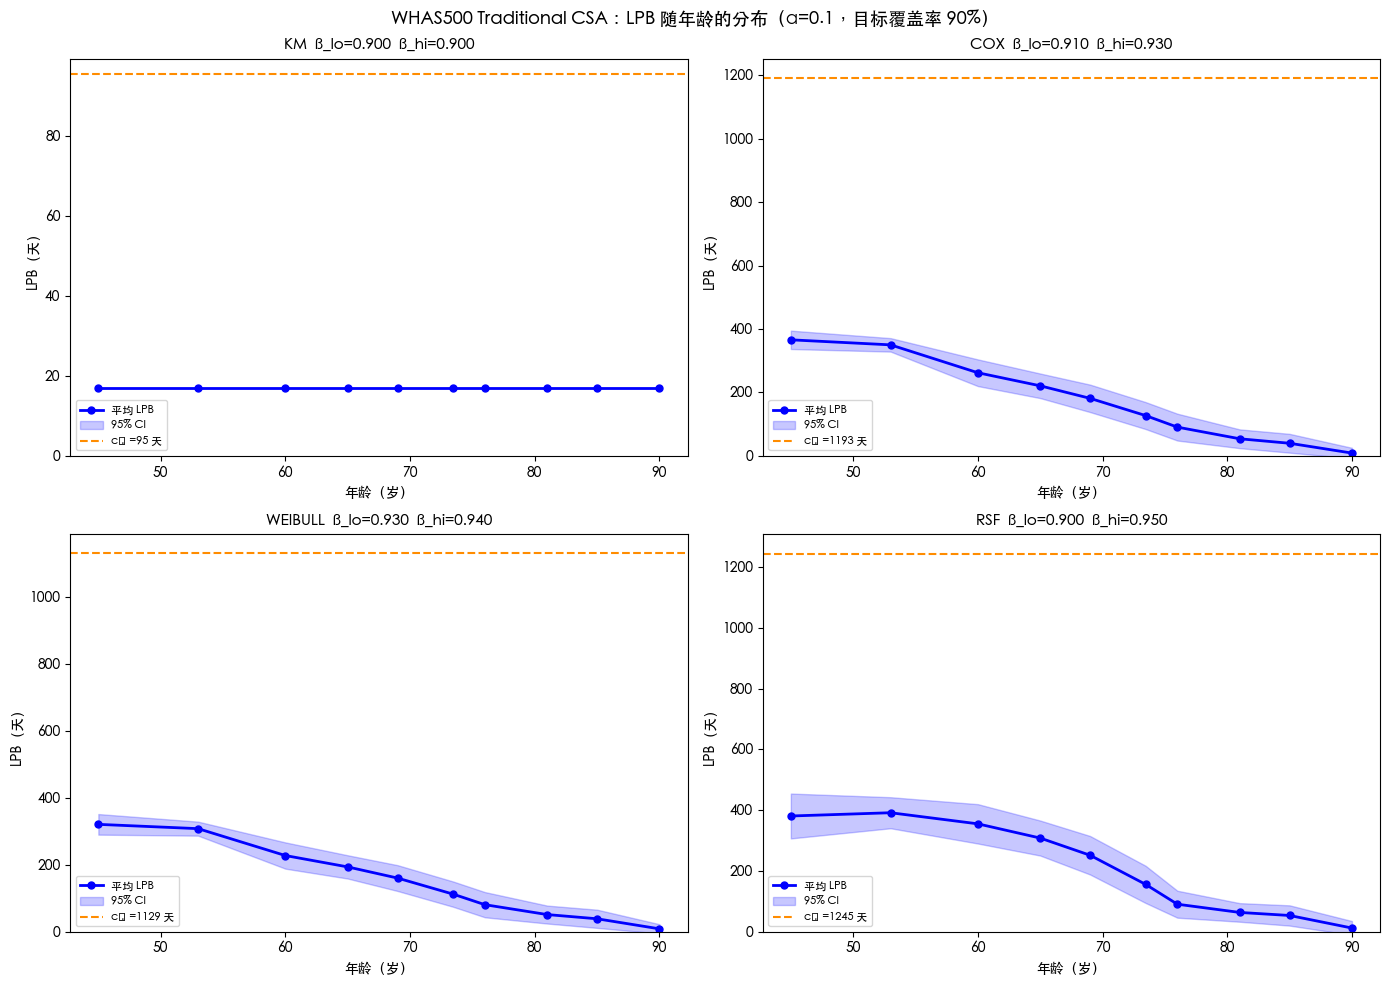

In [10]:

age_idx = feature_names_whas.index('age') if 'age' in feature_names_whas else 0
age_te  = X_te_w[:, age_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('WHAS500 Traditional CSA：LPB 随年龄的分布（α=0.1，目标覆盖率 90%）',
             fontsize=13, fontweight='bold')

for ax, res in zip(axes.flatten(), whas_csa_results):
    mt  = res['model_type']
    lb  = res['_lower']
    c0  = res['c0_chosen']

    # 按年龄十分位滑窗计算平均 LPB ± 1.96 SE
    pcts  = np.percentile(age_te, np.linspace(5, 95, 10))
    bw    = (pcts[-1] - pcts[0]) / len(pcts) * 1.2
    m_lb, s_lb = [], []
    for p in pcts:
        mask = np.abs(age_te - p) <= bw
        if mask.sum() > 1:
            m_lb.append(np.mean(lb[mask]))
            s_lb.append(np.std(lb[mask]) / np.sqrt(mask.sum()))
        else:
            m_lb.append(np.nan); s_lb.append(np.nan)
    m_lb, s_lb = np.array(m_lb), np.array(s_lb)

    ax.plot(pcts, m_lb, 'b-o', lw=2, ms=5, label='平均 LPB')
    ax.fill_between(pcts, m_lb - 1.96*s_lb, m_lb + 1.96*s_lb,
                    alpha=0.22, color='blue', label='95% CI')
    ax.axhline(c0, color='darkorange', ls='--', lw=1.5, label=f'c₀={c0:.0f} 天')
    ax.set_xlabel('年龄（岁）', fontsize=10)
    ax.set_ylabel('LPB（天）', fontsize=10)
    ax.set_title(f'{mt.upper()}  β_lo={res["beta_lo"]:.3f}  β_hi={res["beta_hi"]:.3f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('WHAS500_LPB_vs_age.png', dpi=120, bbox_inches='tight')
plt.show()


## 第三部分：真实数据（WHAS500）CSA 实验结果分析

**主要发现**

- 在 `random_state=2026` 的分割下，四种模型的经验覆盖率下界都达到目标 `1-α=0.90`：KM `β_lo=0.900`、Cox `β_lo=0.910`、Weibull `β_lo=0.930`、RSF `β_lo=0.900`。其中 Weibull 的边际覆盖最高。
- KM 选择的 `c0=95.4` 较小，`P(C≥c0)=0.8400`，最终 LPB 均值 / 中位数都只有 17 天，几乎退化为近常数下界；它满足覆盖要求，但个体化解释价值有限。
- Cox、Weibull 和 RSF 都选择了较大的 `c0`，但并不完全相同：Cox 为 1193.2、Weibull 为 1128.6、RSF 为 1244.8，对应 `P(C≥c0)` 分别为 0.3400、0.3967、0.3033。三者的 LPB 均值分别为 170.1、150.1、203.3 天，个体化程度明显强于 KM，其中 RSF 给出的下界最激进。
- 未删失覆盖率全部低于 0.90：KM = 0.7674、Cox = 0.8372、Weibull = 0.8605、RSF = 0.8837；删失覆盖率则整体更高（1.0000、0.9649、0.9825、0.9123），说明边际保证在较大程度上依赖对删失样本的保守覆盖。
- `β_hi` 仅在 KM 上与 `β_lo` 重合；Cox / Weibull / RSF 的 `β_hi` 分别为 0.93、0.94、0.95，说明当 LPB 抬高后，测试集中仍有一部分删失观测落在不确定区间内，其中 RSF 的上下界间距最大。

**不足与改进方向**

- 真实数据中删失时间 `C` 不可观测，权重估计只能用观测时间 `T̃` 近似，因此这里验证的是经验表现而非严格可证的有限样本保证。
- `c0` 搜索仍呈现明显的两极分化：KM 走向小阈值和近常数 LPB，个体化模型则依赖较大的 `c0` 和较低的 `P(C≥c0)`（约 0.30–0.40）。后续可考虑把覆盖稳定性或有效样本量直接纳入 `c0` 选择准则。
- 测试集仅 100 例（未删失 43），覆盖率估计方差较大，建议多次随机分割取均值以评估稳定性。
- 未与无权重版本及竞争方法对比，IPCW 校正的实际增益尚未量化。

## 第四部分：Alpha 阈值优化分析（WHAS500）

**主要发现**

- 随着 α 从 0.01 增加到 0.30，四种方法的平均 LPB 整体上升，而 `β_lo` 整体下降，体现了“更激进的下界”与“更弱的覆盖约束”之间的直接权衡；不过曲线并非严格单调，局部会因 `c0` 重选而出现跳变。
- 最优 α 不再定义为“满足 `β_lo ≥ 1-α` 的最大 α”，因为该规则会系统性地把结果推到可行区间最右端，难以反映覆盖率曲线真正的拐点位置。
- 本节改用“覆盖率拐点 α”作为最优值：先把 `β_lo` 曲线做单调化，再比较候选点左侧覆盖率增益与右侧覆盖率跌幅，选择“左侧增益小、右侧跌幅大”的 α；若存在满足 `β_lo ≥ 1-α` 的候选点，则优先在该可行区间内选取。
- 这样得到的 α 更接近“继续减小 α 的收益已经有限，但继续增大 α 会明显损失覆盖率”的直观解释，也更适合在论文中说明阈值选择依据。
- 由于不同基础模型的覆盖率曲线形状不同，WHAS500 上最优 α 仍然应视为与基础模型联动的超参数，而不是统一固定成某一个常数。

  alpha=0.01  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.01  cox      beta_lo=1.000  mean_LPB=0.0
  alpha=0.01  weibull  beta_lo=1.000  mean_LPB=0.0
  alpha=0.01  rsf      beta_lo=1.000  mean_LPB=0.0
  alpha=0.02  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.02  cox      beta_lo=0.960  mean_LPB=53.2
  alpha=0.02  weibull  beta_lo=0.960  mean_LPB=67.4
  alpha=0.02  rsf      beta_lo=1.000  mean_LPB=36.8
  alpha=0.03  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.03  cox      beta_lo=0.960  mean_LPB=82.8
  alpha=0.03  weibull  beta_lo=0.960  mean_LPB=87.1
  alpha=0.03  rsf      beta_lo=0.970  mean_LPB=59.1
  alpha=0.04  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.04  cox      beta_lo=0.950  mean_LPB=103.7
  alpha=0.04  weibull  beta_lo=0.960  mean_LPB=98.2
  alpha=0.04  rsf      beta_lo=0.970  mean_LPB=64.0
  alpha=0.05  km       beta_lo=0.990  mean_LPB=2.0
  alpha=0.05  cox      beta_lo=0.950  mean_LPB=103.7
  alpha=0.05  weibull  beta_lo=0.960  mean_LPB=98.2
  alpha=0.05  rsf 

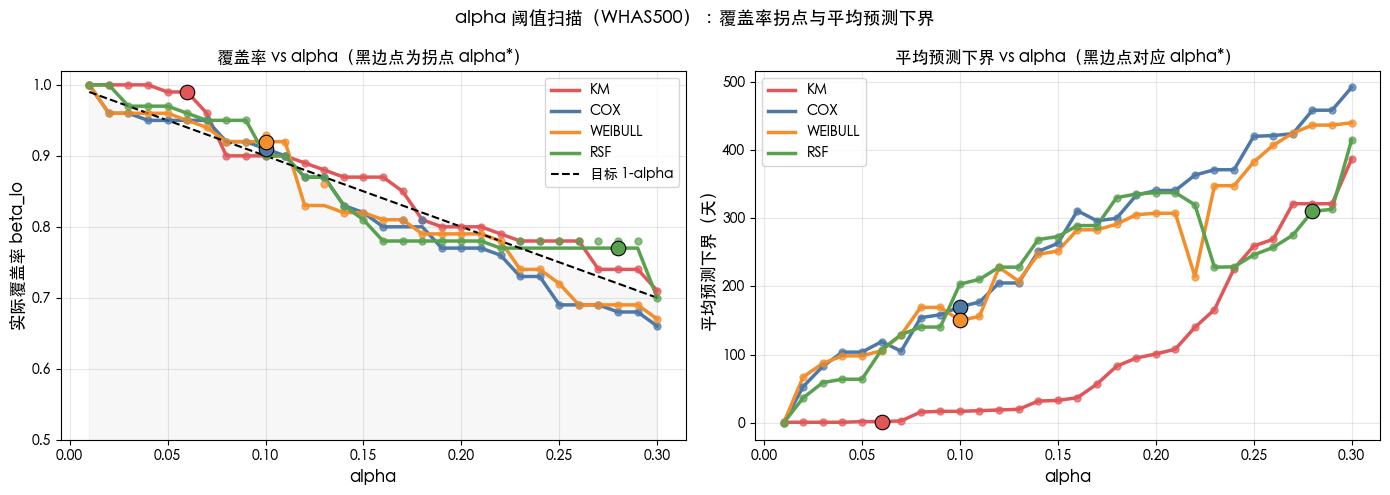


最优 alpha 选择（覆盖率拐点法）：
  规则：优先保留满足 beta_lo >= 1-alpha 的 alpha，
       再选择“左侧覆盖率增益小、右侧覆盖率跌幅大”的拐点。
  KM      : alpha*=0.06  beta_lo=0.990  mean_LPB=2.0  左侧增益=0.010  右侧跌幅=0.090
  COX     : alpha*=0.10  beta_lo=0.910  mean_LPB=170.1  左侧增益=0.010  右侧跌幅=0.040
  WEIBULL : alpha*=0.10  beta_lo=0.930  mean_LPB=150.1  左侧增益=0.000  右侧跌幅=0.090
  RSF     : alpha*=0.28  beta_lo=0.780  mean_LPB=310.0  左侧增益=0.000  右侧跌幅=0.070


In [14]:
alpha_list = [round(x * 0.01, 2) for x in range(1, 31)]
model_types = ['km', 'cox', 'weibull', 'rsf']
model_map_w = {'km': kmf_w, 'cox': cox_w, 'weibull': weibull_w, 'rsf': rsf_w}

sweep_records = []

for alpha in alpha_list:
    for model_type in model_types:
        model = model_map_w[model_type]
        lower_s, upper_s, _, _ = fit_csa_intervals_traditional(
            model,
            X_tr_w, time_tr_w, event_tr_w,
            X_cal_w, time_cal_w, event_cal_w,
            X_te_w,
            alpha=alpha,
            model_type=model_type,
            use_weights=True,
            verbose=False
        )
        m_s = evaluate_interval_coverage_traditional(lower_s, upper_s, time_te_w, event_te_w)
        sweep_records.append({
            'alpha': alpha,
            'model': model_type,
            'beta_lo': m_s['beta_lo'],
            'mean_lpb': float(lower_s.mean()),
        })
        print(f"  alpha={alpha:.2f}  {model_type:7s}  beta_lo={m_s['beta_lo']:.3f}  mean_LPB={lower_s.mean():.1f}")

df_sweep = pd.DataFrame(sweep_records)

def select_elbow_alpha(sub_df, window=2, enforce_feasible=True):
    sub = sub_df.sort_values('alpha').reset_index(drop=True).copy()
    alphas = sub['alpha'].to_numpy()
    beta_lo = sub['beta_lo'].to_numpy()

    # 覆盖率理论上应随 alpha 增大而下降；累计最小值可抑制局部跳变
    beta_lo_smooth = np.minimum.accumulate(beta_lo)

    candidate_idx = np.arange(window, len(sub) - window)
    if enforce_feasible:
        feasible_idx = candidate_idx[beta_lo[candidate_idx] >= 1 - alphas[candidate_idx]]
        if feasible_idx.size > 0:
            candidate_idx = feasible_idx

    scores = []
    for i in candidate_idx:
        left_gain = beta_lo_smooth[i - window] - beta_lo_smooth[i]
        right_drop = beta_lo_smooth[i] - beta_lo_smooth[i + window]
        scores.append({
            'idx': i,
            'alpha': alphas[i],
            'beta_lo': beta_lo[i],
            'beta_lo_smooth': beta_lo_smooth[i],
            'mean_lpb': sub.loc[i, 'mean_lpb'],
            'left_gain': left_gain,
            'right_drop': right_drop,
            'elbow_score': right_drop - left_gain,
            'feasible': beta_lo[i] >= 1 - alphas[i],
        })

    if not scores:
        return None, beta_lo_smooth, sub

    score_df = pd.DataFrame(scores).sort_values(
        ['elbow_score', 'right_drop', 'alpha'],
        ascending=[False, False, True]
    )
    return score_df.iloc[0], beta_lo_smooth, sub

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'km': '#e15759', 'cox': '#4e79a7', 'weibull': '#f28e2b', 'rsf': '#59a14f'}
elbow_info = {}

for mt in model_types:
    opt, beta_lo_smooth, sub = select_elbow_alpha(
        df_sweep[df_sweep['model'] == mt],
        window=2,
        enforce_feasible=True
    )
    elbow_info[mt] = opt

    a_pts = sub['alpha'].values
    c_pts = sub['beta_lo'].values
    l_pts = sub['mean_lpb'].values

    ax1.plot(a_pts, beta_lo_smooth, color=colors[mt], lw=2.5, label=mt.upper())
    ax1.scatter(a_pts, c_pts, color=colors[mt], s=25, zorder=5, alpha=0.70)

    ax2.plot(a_pts, l_pts, color=colors[mt], lw=2.5, label=mt.upper())
    ax2.scatter(a_pts, l_pts, color=colors[mt], s=25, zorder=5, alpha=0.70)

    if opt is not None:
        ax1.scatter(
            opt['alpha'], opt['beta_lo_smooth'],
            color=colors[mt], s=110, edgecolor='black', linewidth=0.8, zorder=6
        )
        ax2.scatter(
            opt['alpha'], opt['mean_lpb'],
            color=colors[mt], s=110, edgecolor='black', linewidth=0.8, zorder=6
        )

alphas_arr = np.array(alpha_list)
ax1.plot(alphas_arr, 1 - alphas_arr, 'k--', lw=1.5, label='目标 1-alpha')
ax1.fill_between(alphas_arr, 0, 1 - alphas_arr, alpha=0.06, color='gray')
ax1.set_xlabel('alpha', fontsize=12)
ax1.set_ylabel('实际覆盖率 beta_lo', fontsize=12)
ax1.set_title('覆盖率 vs alpha（黑边点为拐点 alpha*）', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim(0.5, 1.02)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('alpha', fontsize=12)
ax2.set_ylabel('平均预测下界（天）', fontsize=12)
ax2.set_title('平均预测下界 vs alpha（黑边点对应 alpha*）', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('alpha 阈值扫描（WHAS500）：覆盖率拐点与平均预测下界', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('alpha_sweep_WHAS500.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n最优 alpha 选择（覆盖率拐点法）：')
print('  规则：优先保留满足 beta_lo >= 1-alpha 的 alpha，')
print('       再选择“左侧覆盖率增益小、右侧覆盖率跌幅大”的拐点。')
for mt in model_types:
    opt = elbow_info[mt]
    if opt is not None:
        print(
            f"  {mt.upper():8s}: alpha*={opt['alpha']:.2f}  beta_lo={opt['beta_lo']:.3f}  "
            f"mean_LPB={opt['mean_lpb']:.1f}  左侧增益={opt['left_gain']:.3f}  右侧跌幅={opt['right_drop']:.3f}"
        )
    else:
        print(f"  {mt.upper():8s}: 无满足条件的 alpha")


## 第五部分：合成数据 Alpha-覆盖率分析

在三种样本量场景下（n=100/500/2000）扫描 α，并与 WHAS500 部分保持同一口径：不再把最优 α 定义为可行区间最右端，而是定义为覆盖率曲线的拐点。

这里的拐点含义是：继续减小 α 时覆盖率提升已经不明显，而继续增大 α 时覆盖率会更快下降。为抑制有限样本下的局部波动，先对覆盖率曲线做单调化，再比较候选点左右两侧的覆盖率变化幅度。

n=100  alpha=0.02  km       coverage=1.000
n=100  alpha=0.04  km       coverage=1.000
n=100  alpha=0.06  km       coverage=1.000
n=100  alpha=0.08  km       coverage=0.950
n=100  alpha=0.10  km       coverage=0.950
n=100  alpha=0.12  km       coverage=0.950
n=100  alpha=0.14  km       coverage=0.950
n=100  alpha=0.16  km       coverage=0.800
n=100  alpha=0.18  km       coverage=0.800
n=100  alpha=0.20  km       coverage=0.800
n=100  alpha=0.22  km       coverage=0.700
n=100  alpha=0.24  km       coverage=0.700
n=100  alpha=0.26  km       coverage=0.700
n=100  alpha=0.28  km       coverage=0.700
n=100  alpha=0.02  cox      coverage=1.000
n=100  alpha=0.04  cox      coverage=1.000
n=100  alpha=0.06  cox      coverage=1.000
n=100  alpha=0.08  cox      coverage=1.000
n=100  alpha=0.10  cox      coverage=1.000
n=100  alpha=0.12  cox      coverage=1.000
n=100  alpha=0.14  cox      coverage=1.000
n=100  alpha=0.16  cox      coverage=1.000
n=100  alpha=0.18  cox      coverage=1.000
n=100  alph

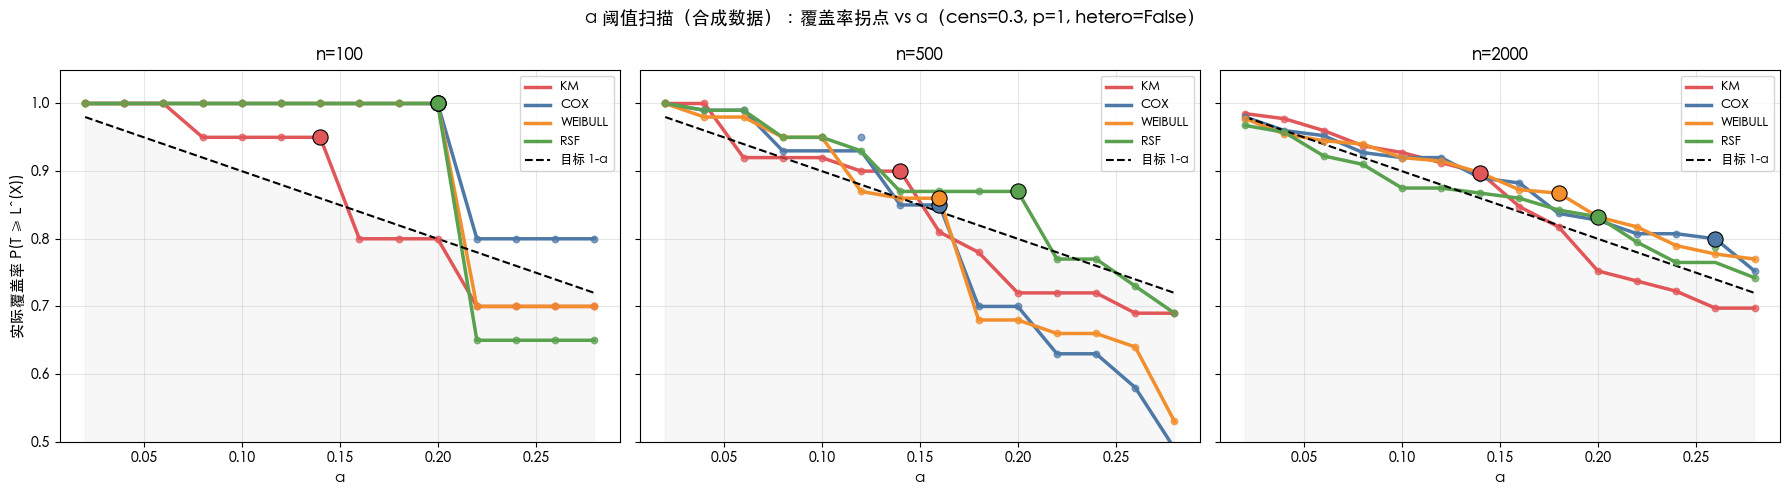


合成数据最优 alpha 选择（覆盖率拐点法）：
  规则：优先保留满足 coverage >= 1-alpha 的 alpha，
       再选择“左侧覆盖率增益小、右侧覆盖率跌幅大”的拐点。
  n= 100  KM        alpha*=0.14  coverage=0.950  左侧增益=0.000  右侧跌幅=0.150
  n= 100  COX       alpha*=0.20  coverage=1.000  左侧增益=0.000  右侧跌幅=0.200
  n= 100  WEIBULL   alpha*=0.20  coverage=1.000  左侧增益=0.000  右侧跌幅=0.300
  n= 100  RSF       alpha*=0.20  coverage=1.000  左侧增益=0.000  右侧跌幅=0.350
  n= 500  KM        alpha*=0.14  coverage=0.900  左侧增益=0.000  右侧跌幅=0.090
  n= 500  COX       alpha*=0.16  coverage=0.850  左侧增益=0.000  右侧跌幅=0.150
  n= 500  WEIBULL   alpha*=0.16  coverage=0.860  左侧增益=0.000  右侧跌幅=0.180
  n= 500  RSF       alpha*=0.20  coverage=0.870  左侧增益=0.000  右侧跌幅=0.100
  n=2000  KM        alpha*=0.14  coverage=0.897  左侧增益=0.015  右侧跌幅=0.050
  n=2000  COX       alpha*=0.26  coverage=0.800  左侧增益=0.007  右侧跌幅=0.048
  n=2000  WEIBULL   alpha*=0.18  coverage=0.868  左侧增益=0.005  右侧跌幅=0.035
  n=2000  RSF       alpha*=0.20  coverage=0.833  左侧增益=0.010  右侧跌幅=0.037


In [21]:
# 三个代表性场景：n=100/500/2000，cens=0.3，p=1，hetero=False
# 索引：n_idx*12 + cens_idx*4 + p_idx*2 + hetero_idx = [4, 16, 28]
scenario_indices = {100: 4, 500: 16, 2000: 28}
alpha_list_syn = [round(x * 0.02, 2) for x in range(1, 15)]

base_models = ['km', 'cox', 'weibull', 'rsf']
colors = {'km': '#e15759', 'cox': '#4e79a7', 'weibull': '#f28e2b', 'rsf': '#59a14f'}

def select_elbow_alpha(sub_df, window=1, enforce_feasible=True):
    sub = sub_df.sort_values('alpha').reset_index(drop=True).copy()
    alphas = sub['alpha'].to_numpy()
    coverage = sub['coverage'].to_numpy()

    # 覆盖率理论上应随 alpha 增大而下降；累计最小值可抑制局部跳变
    coverage_smooth = np.minimum.accumulate(coverage)

    candidate_idx = np.arange(window, len(sub) - window)
    if enforce_feasible:
        feasible_idx = candidate_idx[coverage[candidate_idx] >= 1 - alphas[candidate_idx]]
        if feasible_idx.size > 0:
            candidate_idx = feasible_idx

    scores = []
    for i in candidate_idx:
        left_gain = coverage_smooth[i - window] - coverage_smooth[i]
        right_drop = coverage_smooth[i] - coverage_smooth[i + window]
        scores.append({
            'idx': i,
            'alpha': alphas[i],
            'coverage': coverage[i],
            'coverage_smooth': coverage_smooth[i],
            'left_gain': left_gain,
            'right_drop': right_drop,
            'elbow_score': right_drop - left_gain,
            'feasible': coverage[i] >= 1 - alphas[i],
        })

    if not scores:
        return None, coverage_smooth, sub

    score_df = pd.DataFrame(scores).sort_values(
        ['elbow_score', 'right_drop', 'alpha'],
        ascending=[False, False, True]
    )
    return score_df.iloc[0], coverage_smooth, sub

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('α 阈值扫描（合成数据）：覆盖率拐点 vs α（cens=0.3, p=1, hetero=False）',
             fontsize=13, fontweight='bold')

synthetic_elbow_records = []

for ax, (n_val, idx) in zip(axes, scenario_indices.items()):
    X_s, surv_s, time_s, event_s = datasets[idx]
    time_true_s = time_trues[idx]
    cens_time_s = cens_times[idx]

    (X_tr_s, time_tr_s, event_tr_s,
     X_cal_s, time_cal_s, event_cal_s,
     X_te_s, time_te_s, event_te_s,
     _, _, ttrue_te_s,
     cens_tr_s, cens_cal_s, _) = split_survival_data(
        X_s, time_s, event_s,
        time_true=time_true_s, cens_time=cens_time_s,
        test_size=0.2, cal_size=0.25, random_state=2026
    )

    kmf_s     = fit_kaplan_meier(time_tr_s, event_tr_s)
    cox_s     = fit_cox(X_tr_s, time_tr_s, event_tr_s)
    weibull_s = fit_weibull(X_tr_s, time_tr_s, event_tr_s)
    rsf_s     = fit_rsf(X_tr_s, time_tr_s, event_tr_s)
    model_map_s = {'km': kmf_s, 'cox': cox_s, 'weibull': weibull_s, 'rsf': rsf_s}

    scenario_records = []
    for mt in base_models:
        for alpha in alpha_list_syn:
            lower_s2, _, _, _ = fit_csa_intervals_traditional(
                model_map_s[mt],
                X_tr_s, time_tr_s, event_tr_s,
                X_cal_s, time_cal_s, event_cal_s,
                X_te_s, alpha=alpha, model_type=mt,
                use_weights=False,
                cens_time_train=cens_tr_s, cens_time_cal=cens_cal_s,
                verbose=False
            )
            m2 = evaluate_interval_coverage_traditional_synthetic(lower_s2, ttrue_te_s, event_te_s)
            scenario_records.append({
                'n': n_val,
                'model': mt,
                'alpha': alpha,
                'coverage': m2['coverage'],
            })
            print(f"n={n_val}  alpha={alpha:.2f}  {mt:7s}  coverage={m2['coverage']:.3f}")

    scenario_df = pd.DataFrame(scenario_records)

    for mt in base_models:
        opt, coverage_smooth, sub = select_elbow_alpha(
            scenario_df[scenario_df['model'] == mt],
            window=1,
            enforce_feasible=True
        )

        a_pts = sub['alpha'].values
        c_pts = sub['coverage'].values
        ax.plot(a_pts, coverage_smooth, color=colors[mt], lw=2.5, label=mt.upper())
        ax.scatter(a_pts, c_pts, color=colors[mt], s=22, zorder=5, alpha=0.70)

        if opt is not None:
            ax.scatter(
                opt['alpha'], opt['coverage_smooth'],
                color=colors[mt], s=120, edgecolor='black', linewidth=0.8, zorder=6
            )
            synthetic_elbow_records.append({
                'n': n_val,
                'model': mt,
                'alpha_star': opt['alpha'],
                'coverage': opt['coverage'],
                'left_gain': opt['left_gain'],
                'right_drop': opt['right_drop'],
            })

    alphas_arr = np.array(alpha_list_syn)
    ax.plot(alphas_arr, 1 - alphas_arr, 'k--', lw=1.5, label='目标 1-α')
    ax.fill_between(alphas_arr, 0, 1 - alphas_arr, alpha=0.06, color='gray')
    ax.set_xlabel('α', fontsize=11)
    ax.set_title(f'n={n_val}', fontsize=12)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('实际覆盖率 P(T ≥ L̂(X))', fontsize=11)
plt.tight_layout()
plt.savefig('alpha_sweep_synthetic.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n合成数据最优 alpha 选择（覆盖率拐点法）：')
print('  规则：优先保留满足 coverage >= 1-alpha 的 alpha，')
print('       再选择“左侧覆盖率增益小、右侧覆盖率跌幅大”的拐点。')
for rec in synthetic_elbow_records:
    print(
        f"  n={int(rec['n']):4d}  {rec['model'].upper():8s}  alpha*={rec['alpha_star']:.2f}  "
        f"coverage={rec['coverage']:.3f}  左侧增益={rec['left_gain']:.3f}  右侧跌幅={rec['right_drop']:.3f}"
    )
